# YOLO Object Detection — Training

This notebook defines the YOLO loss function and runs the training loop. It imports the model and dataset from `model.ipynb` and `data.ipynb`.

## YOLO Loss Function

Our model outputs **170 values per grid cell** — 2 boxes × 85 values each:

```
[objectness, x, y, w, h, class_0 ... class_79]  ×  2 anchors
```

The total loss has four components:

| Component | Loss type | Applied to |
|---|---|---|
| **Objectness** | BCE | All cells — did the model correctly predict object/no-object? |
| **No-object** | BCE | Background cells (weighted lower with λ=0.5) |
| **Box (xy)** | BCE | Only cells with an object — centre offset within the cell |
| **Box (wh)** | MSE on log scale | Only cells with an object — width/height vs anchor |
| **Class** | BCE | Only cells with an object — which of 80 classes? |

The **object mask** is key — box and class losses are only applied to cells that actually contain an object, preventing the model from being penalised for not predicting boxes everywhere.

**λ weights** let you control how much each part matters. We use `λ_xy=5, λ_wh=5` to emphasise precise localisation.

In [1]:
import torch

### Draft Loss Functions

These standalone functions show how each loss component works in isolation. The actual training uses `total_loss` below, which combines them all.

In [2]:
# objectness loss
'''
Because this is either 1 (there is an object here) or 0 (there is no object here) we should use binary cross entropy BCE to measure the loss. 
takes in (2,13,13) since each cell has 2 objectness values; 1 for each box and there is 13x13 cells outputs (2x13x13)
'''

def object_loss(predicted_objectness, target_objectness):
    return torch.nn.BCEWithLogitsLoss(predicted_objectness, target_objectness)

In [3]:
# box coordinates loss
'''
calcualted for cells that have an object. It compares predicted box coordinates agains the target box coordinates                                                                                                                                                 
  input:  predicted_xy [2, 2, 13, 13]
          predicted_wh [2, 2, 13, 13]                                                                                                                 
          target_xy    [2, 2, 13, 13]
          target_wh    [2, 2, 13, 13]                                                                                                                 
          anchor       [2]  e.g. tensor([0.28, 0.22])
  output: scalar loss value                                                                                                                           
  '''  

def box_loss(predicted_xy, predicted_wh, target_xy, target_wh, anchor):
  loss_xy = torch.nn.BCEWithLogitsLoss(reduction='none')(predicted_xy, target_xy)                                                                                 
  loss_wh = torch.nn.MSELoss(reduction='none')(predicted_wh, torch.log(target_wh / anchor + 1e-16))
  return loss_xy , loss_wh  


In [4]:
# class loss
'''
Only calculated for cells that have an object. Compares predicted class scores against the true class:                                                                                               
  target = one-hot vector [0, 0, 1, 0, ...] ← 1 at the correct class index
  loss = BCE(sigmoid(pred_classes), target)  
  takes a input shape (2, 80, 13,13)
'''

def class_loss(predicted_classes, target_classes):
  loss_fn = torch.nn.Softmax()
  return loss_fn(predicted_classes, target_classes)


### Total Loss

Combines all components into a single scalar. For each image:
1. Parse the model's `[170, 13, 13]` output into objectness, xy, wh, and class tensors
2. Build target tensors by mapping each ground-truth label to its grid cell and best-matching anchor
3. Compute masked losses — box/class losses only where `obj_mask == 1`
4. Return the weighted sum and a breakdown dict for monitoring

In [5]:
# total loss
'''
  loss = λ_obj  * objectness_loss                                                                                                                                                                      
       + λ_noobj * noobj_loss      ← background cells weighted separately
       + λ_box  * box_loss                                                                                                                                                                             
       + λ_class * class_loss                                                                                                                                                                          
                                                                                                                                                                                                       
  The λ weights let you control how much each part matters. YOLOv1 used λ_box=5, λ_noobj=0.5.  
  takes inputs predictions (170, 13,13) labels (5,)        
'''

GRID_SIZE   = 13                                                                                                                                    
NUM_CLASSES = 80                                                                                                                                    
anchors     = torch.tensor([[0.28, 0.22], [0.38, 0.48]])
                                                                                                                                                    
λ_obj   = 1.0
λ_noobj = 0.5                                                                                                                                       
λ_xy    = 5.0                                                                                                                                       
λ_wh    = 5.0                                                                                                                                       
λ_cls   = 1.0                                                                                                                                       
                
def total_loss(predictions, labels):
    dev = predictions.device

    # --- Extract predictions ---
    pred_obj = torch.stack([predictions[0,  :, :], predictions[85, :, :]])     # [2, 13, 13]
    pred_xy  = torch.stack([predictions[1:3,   :, :], predictions[86:88, :, :]])  # [2, 2, 13, 13]
    pred_wh  = torch.stack([predictions[3:5,   :, :], predictions[88:90, :, :]])  # [2, 2, 13, 13]
    pred_cls = torch.stack([predictions[5:85,   :, :], predictions[90:170, :, :]]) # [2, 80, 13, 13]

    # --- Build targets on same device as predictions ---
    target_obj = torch.zeros(2, GRID_SIZE, GRID_SIZE, device=dev)
    target_xy  = torch.zeros(2, 2, GRID_SIZE, GRID_SIZE, device=dev)
    target_wh  = torch.zeros(2, 2, GRID_SIZE, GRID_SIZE, device=dev)
    target_cls = torch.zeros(2, NUM_CLASSES, GRID_SIZE, GRID_SIZE, device=dev)
    obj_mask   = torch.zeros(2, GRID_SIZE, GRID_SIZE, device=dev)
                
    for label in labels:                                                                                                                            
        category_id, cx, cy, w, h = label

        grid_x = min(int(cx * GRID_SIZE), GRID_SIZE - 1)
        grid_y = min(int(cy * GRID_SIZE), GRID_SIZE - 1)
                                                                                                                                                    
        ious = []                                                                                                                                   
        for anchor in anchors:
            inter = min(w.item(), anchor[0].item()) * min(h.item(), anchor[1].item())
            union = w * h + anchor[0] * anchor[1] - inter                                                                                           
            ious.append(inter / union)
        best = int(torch.tensor(ious).argmax())
                
        tx = cx * GRID_SIZE - grid_x
        ty = cy * GRID_SIZE - grid_y

        target_obj[best, grid_y, grid_x]    = 1.0
        target_xy [best, :, grid_y, grid_x] = torch.tensor([tx, ty], device=dev)
        target_wh [best, :, grid_y, grid_x] = torch.tensor([w, h], device=dev)
        target_cls[best, int(category_id), grid_y, grid_x] = 1.0
        obj_mask  [best, grid_y, grid_x]    = 1.0
                                                                                                                                                    
    noobj_mask = 1 - obj_mask
                                                                                                                                                    
    # --- Calculate losses ---
    bce = torch.nn.BCEWithLogitsLoss(reduction='none')
    mse = torch.nn.MSELoss(reduction='none')

    loss_obj   = (bce(pred_obj, target_obj) * obj_mask).mean()
    loss_noobj = (bce(pred_obj, target_obj) * noobj_mask).mean()
    loss_xy    = (bce(pred_xy, target_xy) * obj_mask.unsqueeze(1)).mean()
    loss_wh    = (mse(pred_wh, torch.log(target_wh / anchors.view(2,2,1,1).to(dev) + 1e-16))
                  * obj_mask.unsqueeze(1)).mean()
    loss_cls   = (bce(pred_cls, target_cls) * obj_mask.unsqueeze(1)).mean()
                                                                                                                                                    
    loss = (λ_obj   * loss_obj
          + λ_noobj * loss_noobj
          + λ_xy    * loss_xy
          + λ_wh    * loss_wh
          + λ_cls   * loss_cls)
                
    return loss, {
        'obj':   loss_obj.item(),
        'noobj': loss_noobj.item(),
        'xy':    loss_xy.item(),
        'wh':    loss_wh.item(),
        'cls':   loss_cls.item(),
    }

## Training

The training loop:
1. Loads the dataset and model from the other notebooks
2. Runs Adam optimiser with `lr=0.0001`
3. For each image: forward pass → compute loss → backprop → update weights
4. Saves `model1.pth` after every epoch so you can stop at any time

### Imports

Load the dataset and model architecture from the other notebooks. `%run` executes the notebook in the current kernel, making all defined variables available here.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
PyTorch is using mps.
=== Keys ===
['info', 'licenses', 'images', 'annotations', 'categories']

=== Info ===
{ 'contributor': 'COCO Consortium',
  'date_created': '2017/09/01',
  'description': 'COCO 2017 Dataset',
  'url': 'http://cocodataset.org',
  'version': '1.0',
  'year': 2017}

=== Sample Image ===
{ 'coco_url': 'http://images.cocodataset.org/val2017/000000397133.jpg',
  'date_captured': '2013-11-14 17:02:52',
  'file_name': '000000397133.jpg',
  'flickr_url': 'http://farm7.staticflickr.com/6116/6255196340_da26cf2c9e_z.jpg',
  'height': 427,
  'id': 397133,
  'license': 4,
  'width': 640}

=== Sample Annotation ===
{ 'area': 702.1057499999998,
  'bbox': [473.07, 395.93, 38.65, 28.67],
  'category_id': 18,
  'id': 1768,

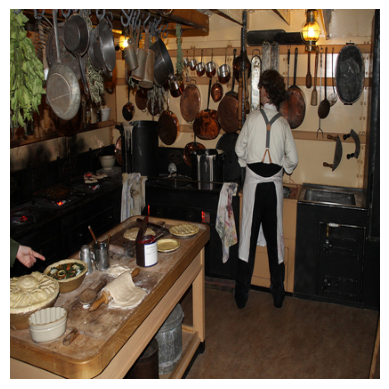

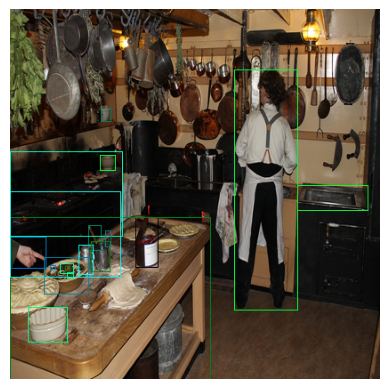

Model(
  (layers): ModuleList(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (Silu): SiLU()
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (Silu): SiLU()
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (Silu): SiLU()
    )
    (5): Conv(
      (conv): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
      (batch_norm): BatchNorm2d(64, eps=1e-05, momentu

In [6]:
# --- this gets the dataset and model from the other notebooks ---
%pip install nbformat -q
%run data.ipynb
%run model.ipynb 

### Training Loop

- `batch_size=1` — one image at a time (YOLO loss doesn't easily vectorise across a batch with variable label counts)
- `model(images).squeeze(0)` — removes the batch dimension to get `[170, 13, 13]`
- `labels.squeeze(0)` — removes the batch dimension to get `[N, 5]` (N objects in this image)
- Loss breakdown is printed each epoch to monitor which components are improving

In [ ]:
# --- building our training --- 

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model  = model.to(device)

# full 5000 image val set
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)
optimizer  = torch.optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(100):
    epoch_loss = 0.0
    for images, labels in dataloader:
        optimizer.zero_grad()

        images      = images.to(device)
        predictions = model(images).squeeze(0)   # [170, 13, 13]
        labels      = labels.squeeze(0)          # [N, 5]

        loss, breakdown = total_loss(predictions, labels)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    print(f"Epoch {epoch} | Avg Loss: {avg_loss:.4f} | Last: {breakdown}")
    torch.save(model.state_dict(), 'model1.pth')  # save after every epoch

### Save Model

Run this cell to manually save the model at any point. The training loop also saves automatically after each epoch.

In [8]:
torch.save(model.state_dict(), 'model1.pth')  